# PACS and BloodMNIST Experiments
The code was run on M4 max Mac Studio with 64 GB Dynamic RAM, 16 core CPU processor and 30 core GPU processor.

We took help of CHATGPT and open code sources available in various research papers on Federated learnings.

This notebook contains the image-based part of the assignment. It uses only the `PACS` and `BloodMNIST` datasets and compares centralized learning with four federated methods: `FedAvg`, `FedProx`, `FedProto`, and `DP-FedAvg`.

## What this notebook does

- loads `PACS` and `BloodMNIST`
- prepares IND and OOD test sets
- trains a centralized baseline
- trains `FedAvg`, `FedProx`, `FedProto`, and `DP-FedAvg`
- compares accuracy, privacy metrics, runtime, and communication cost
- exports the final results to Excel

In [1]:
import copy
import gc
import random
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import ConcatDataset, DataLoader, TensorDataset, Subset
from torchvision import datasets as tv_datasets, models as tv_models, transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

DEVICE

device(type='mps')

### General Training Parameters
- Image Batch Size: 48
- Learning Rate: 3e-4
- Weight Decay: 1e-4
- Local Epochs (per client): 5
- Total Rounds: 10 (But can vary as per Fed Alogorithm)
- Centralized Training Epochs: 40
- Number of Clients: 3 (for PACS dataset)

### Learning Rate Search
- Candidates: [0.0001, 0.0003, 0.001, 0.003, 0.01]
- Search Epochs: 7

### Regularization & Augmentation
- Dropout: 0.3
- Mixup Alpha: 0.2
- Label Smoothing: 0.1

### Federated Learning Parameters
- FedProx μ: 1e-2
- FedProto λ: 0.5

### Differential Privacy
- Gradient Clipping (dp_clip): 1.0
- Noise Multiplier: 0.08

### Data Distribution (Dirichlet)
- Alpha: 0.6
- Minimum Samples per Client: 32

### Early Stopping
- Patience: 8

In [2]:
PACS_ROOT = Path("data/pacs")
PACS_DATASET = "pacs"
MEDMNIST_DATASET = "bloodmnist"
PACS_DOMAINS = ["art_painting", "cartoon", "photo", "sketch"]
PACS_OOD_DOMAIN = "sketch"

CONFIG = {
    "image_batch_size": 48,
    "image_lr": 3e-4,
    'image_lr_candidates': [0.0001, 0.0003, 0.001, 0.003, 0.01],
    "image_lr_search_epochs": 7,
    "weight_decay": 1e-4,
    "image_local_epochs": 5,
    "rounds": 10,
    "image_centralized_epochs": 40,
    "num_clients": 3,
    "fedprox_mu": 1e-2,
    "fedproto_lambda": 0.5,
    "dp_clip": 1.0,
    "dp_noise_multiplier": 0.08,
    "mixup_alpha": 0.2,
    "label_smoothing": 0.1,
    "image_dropout": 0.3,
    "centralized_patience": 8,
    "dirichlet_alpha": 0.6,
    "dirichlet_min_size": 32,
}

print("Device:", DEVICE)
print("PACS root:", PACS_ROOT)
print("PACS OOD domain:", PACS_OOD_DOMAIN)
print("MEDMNIST subset:", MEDMNIST_DATASET)

Device: mps
PACS root: data/pacs
PACS OOD domain: sketch
MEDMNIST subset: bloodmnist


## Dataset preparation

For `PACS`, the domains `art_painting`, `cartoon`, and `photo` are used for training, while `sketch` is kept as the unseen OOD test domain.

For `BloodMNIST`, the original test split is used as IND data and a rotated plus brightness-shifted version of the same test split is used as OOD data.


In [3]:
def release_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and hasattr(torch.mps, "empty_cache"):
        torch.mps.empty_cache()


def _resolve_pacs_root(root_dir: Path):
    candidates = [
        root_dir,
        Path.cwd() / root_dir,
        Path.cwd().parent / root_dir,
        Path("core") / root_dir,
        Path("..") / root_dir,
        Path("/Users/shashank.ajmani/Desktop/NTU Assigments/Data Privacy/Learning/DomainFL") / root_dir,
    ]
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    return root_dir


def _stratified_index_split(labels, test_size, seed=SEED):
    idx = np.arange(len(labels))
    train_idx, test_idx = train_test_split(
        idx,
        test_size=test_size,
        random_state=seed,
        stratify=np.asarray(labels),
    )
    return np.array(sorted(train_idx)), np.array(sorted(test_idx))


def load_medmnist_dataset(dataset_name="bloodmnist"):
    import medmnist
    from medmnist import INFO

    info = INFO[dataset_name]
    data_class = getattr(medmnist, info["python_class"])
    train_ds = data_class(split="train", download=True)
    val_ds = data_class(split="val", download=True)
    test_ds = data_class(split="test", download=True)

    def split_to_numpy(ds):
        images = np.asarray(ds.imgs, dtype=np.float32) / 255.0
        if images.ndim == 3:
            images = images[:, None, :, :]
        elif images.ndim == 4 and images.shape[-1] in (1, 3):
            images = np.transpose(images, (0, 3, 1, 2))
        images = images.astype(np.float32)
        labels = np.asarray(ds.labels).reshape(-1).astype(np.int64)
        return images, labels

    def make_ood_shift(images):
        shifted = np.rot90(images, k=1, axes=(-2, -1)).copy()
        shifted = np.clip(shifted * 0.75 + 0.10, 0.0, 1.0)
        return shifted.astype(np.float32)

    X_train, y_train = split_to_numpy(train_ds)
    X_val, y_val = split_to_numpy(val_ds)
    X_test, y_test = split_to_numpy(test_ds)
    X_ood_test = make_ood_shift(X_test)

    prepared = {
        "X_train": X_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "X_ind_test": X_test,
        "X_ood_test": X_ood_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_ind_test": y_test,
        "y_ood_test": y_test.copy(),
        "input_channels": int(X_train.shape[1]),
        "image_size": tuple(X_train.shape[2:]),
        "num_classes": int(len(np.unique(y_train))),
        "model_type": "image",
    }
    info_dict = {
        "dataset_name": dataset_name,
        "rows_train": len(X_train),
        "rows_val": len(X_val),
        "rows_ind_test": len(X_test),
        "rows_ood_test": len(X_ood_test),
        "classes": info.get("label"),
    }
    return prepared, info_dict


def load_pacs_dataset(root_dir: Path, ood_domain="sketch", domains=None):
    root_dir = _resolve_pacs_root(root_dir)
    domains = list(PACS_DOMAINS if domains is None else domains)
    missing = [d for d in domains if not (root_dir / d).exists()]
    if missing:
        raise FileNotFoundError(
            f"PACS folders not found under {root_dir}. Missing: {missing}"
        )
    if ood_domain not in domains:
        raise ValueError(f"ood_domain={ood_domain} must be one of {domains}")

    seen_domains = [d for d in domains if d != ood_domain]
    weights = tv_models.ResNet18_Weights.DEFAULT
    normalize = transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize,
    ])
    eval_transform = weights.transforms()

    probe_dataset = tv_datasets.ImageFolder(root_dir / seen_domains[0])
    class_names = list(probe_dataset.classes)

    client_subsets = []
    client_domains = []
    train_parts = []
    ind_parts = []
    y_train_all = []

    for domain in seen_domains:
        train_domain_ds = tv_datasets.ImageFolder(root_dir / domain, transform=train_transform)
        eval_domain_ds = tv_datasets.ImageFolder(root_dir / domain, transform=eval_transform)

        train_idx, ind_idx = _stratified_index_split(train_domain_ds.targets, test_size=0.2, seed=SEED)
        train_subset = Subset(train_domain_ds, train_idx.tolist())
        ind_subset = Subset(eval_domain_ds, ind_idx.tolist())

        client_subsets.append(train_subset)
        client_domains.append(domain)
        train_parts.append(train_subset)
        ind_parts.append(ind_subset)
        y_train_all.extend(np.asarray(train_domain_ds.targets)[train_idx].tolist())

    ood_eval_ds = tv_datasets.ImageFolder(root_dir / ood_domain, transform=eval_transform)
    ood_val_idx, ood_test_idx = _stratified_index_split(ood_eval_ds.targets, test_size=0.5, seed=SEED)
    ood_val_subset = Subset(ood_eval_ds, ood_val_idx.tolist())
    ood_test_subset = Subset(ood_eval_ds, ood_test_idx.tolist())

    train_dataset = ConcatDataset(train_parts)
    ind_test_dataset = ConcatDataset(ind_parts)
    sample_x, _ = train_dataset[0][:2]

    prepared = {
        "model_type": "image",
        "num_classes": len(class_names),
        "input_channels": int(sample_x.shape[0]),
        "image_size": tuple(sample_x.shape[1:]),
        "train_dataset": train_dataset,
        "ind_test_dataset": ind_test_dataset,
        "ood_val_dataset": ood_val_subset,
        "ood_test_dataset": ood_test_subset,
        "client_subsets": client_subsets,
        "client_groups": client_domains,
        "y_train": np.asarray(y_train_all, dtype=np.int64),
        "class_names": class_names,
        "ood_domain": ood_domain,
        "seen_domains": seen_domains,
    }
    info_dict = {
        "dataset_name": "PACS",
        "rows_train": len(train_dataset),
        "rows_ind_test": len(ind_test_dataset),
        "rows_ood_val": len(ood_val_subset),
        "rows_ood_test": len(ood_test_subset),
        "seen_domains": seen_domains,
        "ood_domain": ood_domain,
        "client_domains": client_domains,
        "class_names": class_names,
    }
    return prepared, info_dict

Dirichlet partitioning is used to simulate non-IID client data in federated learning. Instead of giving every client a similar class distribution, it creates unequal and imbalanced data splits across clients. This is useful because real federated systems usually do not have identical data on every client. For example, different hospitals, devices, or institutions may observe different subsets of classes or different data proportions.

The Dirichlet parameter `α` controls how uneven the split is. A smaller `α` creates more skewed client distributions, while a larger `α` produces more balanced splits. In this notebook, Dirichlet partitioning is used for `BloodMNIST` to create realistic heterogeneous clients and test how well the federated methods handle statistical heterogeneity.


In [4]:
def unpack_batch(batch):
    if isinstance(batch, (list, tuple)) and len(batch) == 3:
        return batch[0], batch[1], batch[2]
    if isinstance(batch, (list, tuple)) and len(batch) == 2:
        return batch[0], batch[1], None
    raise ValueError("Unexpected batch format")


def make_loader(X, y=None, batch_size=64, shuffle=True):
    if y is None:
        dataset = X
    else:
        dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def dirichlet_client_split(y, num_clients=5, alpha=0.6, min_size=32):
    y = np.asarray(y)
    classes = np.unique(y)
    while True:
        client_indices = [[] for _ in range(num_clients)]
        for cls in classes:
            cls_idx = np.where(y == cls)[0]
            np.random.shuffle(cls_idx)
            proportions = np.random.dirichlet(alpha=np.repeat(alpha, num_clients))
            cut_points = (np.cumsum(proportions)[:-1] * len(cls_idx)).astype(int)
            splits = np.split(cls_idx, cut_points)
            for client_id, split in enumerate(splits):
                client_indices[client_id].extend(split.tolist())
        sizes = [len(idx) for idx in client_indices]
        if min(sizes) >= min_size:
            return [np.array(sorted(idx)) for idx in client_indices]


def get_batch_size(cfg):
    return cfg.get("image_batch_size", 48)


def build_optimizer(model, cfg):
    return torch.optim.AdamW(
        model.parameters(),
        lr=cfg.get("image_lr", 3e-4),
        weight_decay=cfg.get("weight_decay", 1e-4),
    )


def build_criterion(cfg):
    return nn.CrossEntropyLoss(label_smoothing=cfg.get("label_smoothing", 0.0))


def build_scheduler(optimizer, epochs):
    if epochs and epochs > 1:
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    return None


def apply_mixup(xb, yb, alpha=0.2):
    if alpha is None or alpha <= 0:
        return xb, yb, yb, 1.0
    lam = float(np.random.beta(alpha, alpha))
    index = torch.randperm(xb.size(0), device=xb.device)
    mixed_x = lam * xb + (1.0 - lam) * xb[index]
    return mixed_x, yb, yb[index], lam


def mixup_loss(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)


def ensure_cached_client_indices(prepared, cfg):
    if "client_subsets" in prepared:
        return None
    cache = prepared.setdefault("_client_split_cache", {})
    key = (
        cfg.get("num_clients", 5),
        cfg.get("dirichlet_alpha", 0.6),
        cfg.get("dirichlet_min_size", 32),
    )
    if key not in cache:
        np_state = np.random.get_state()
        np.random.seed(SEED)
        cache[key] = dirichlet_client_split(
            prepared["y_train"],
            num_clients=cfg.get("num_clients", 5),
            alpha=cfg.get("dirichlet_alpha", 0.6),
            min_size=cfg.get("dirichlet_min_size", 32),
        )
        np.random.set_state(np_state)
    return cache[key]


def get_train_loader(prepared, cfg, shuffle=True):
    batch_size = get_batch_size(cfg)
    if "train_dataset" in prepared:
        return make_loader(prepared["train_dataset"], None, batch_size=batch_size, shuffle=shuffle)
    return make_loader(prepared["X_train"], prepared["y_train"], batch_size=batch_size, shuffle=shuffle)


def get_ind_loader(prepared, cfg):
    batch_size = get_batch_size(cfg)
    if "ind_test_dataset" in prepared:
        return make_loader(prepared["ind_test_dataset"], None, batch_size=batch_size, shuffle=False)
    return make_loader(prepared["X_ind_test"], prepared["y_ind_test"], batch_size=batch_size, shuffle=False)


def get_val_loader(prepared, cfg):
    batch_size = get_batch_size(cfg)
    if "ood_val_dataset" in prepared:
        return make_loader(prepared["ood_val_dataset"], None, batch_size=batch_size, shuffle=False)
    return make_loader(prepared["X_val"], prepared["y_val"], batch_size=batch_size, shuffle=False)


def get_ood_loader(prepared, cfg):
    batch_size = get_batch_size(cfg)
    if "ood_test_dataset" in prepared:
        return make_loader(prepared["ood_test_dataset"], None, batch_size=batch_size, shuffle=False)
    return make_loader(prepared["X_ood_test"], prepared["y_ood_test"], batch_size=batch_size, shuffle=False)


def build_fixed_client_loaders(prepared, cfg):
    batch_size = get_batch_size(cfg)
    if "client_subsets" in prepared:
        client_loaders = [make_loader(subset, None, batch_size=batch_size, shuffle=True) for subset in prepared["client_subsets"]]
        client_sizes = [len(subset) for subset in prepared["client_subsets"]]
        return client_loaders, client_sizes

    client_indices = ensure_cached_client_indices(prepared, cfg)
    client_loaders = []
    client_sizes = []
    for idx in client_indices:
        client_loaders.append(make_loader(prepared["X_train"][idx], prepared["y_train"][idx], batch_size=batch_size, shuffle=True))
        client_sizes.append(len(idx))
    return client_loaders, client_sizes

In [5]:
pacs_prepared, pacs_info = load_pacs_dataset(PACS_ROOT, ood_domain=PACS_OOD_DOMAIN)
med_prepared, med_info = load_medmnist_dataset(MEDMNIST_DATASET)

print("PACS train:", pacs_info["rows_train"])
print("PACS IND test:", pacs_info["rows_ind_test"])
print("PACS OOD test:", pacs_info["rows_ood_test"])
print("PACS clients:", pacs_info["client_domains"])
print()
print("BloodMNIST train:", med_info["rows_train"])
print("BloodMNIST IND test:", med_info["rows_ind_test"])
print("BloodMNIST OOD test:", med_info["rows_ood_test"])

PACS train: 4849
PACS IND test: 1213
PACS OOD test: 1965
PACS clients: ['art_painting', 'cartoon', 'photo']

BloodMNIST train: 11959
BloodMNIST IND test: 3421
BloodMNIST OOD test: 3421


## Model and evaluation

Both datasets use the same `ResNet18` framework. We tried using EfficientNet B0 which gave betetr results; however it was a complex model and required more resouces.

In [6]:
class ResNet18Classifier(nn.Module):
    def __init__(self, num_classes, input_channels=3, dropout_p=0.3):
        super().__init__()
        self.backbone = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
        if input_channels != 3:
            stem = self.backbone.conv1
            self.backbone.conv1 = nn.Conv2d(
                input_channels,
                stem.out_channels,
                kernel_size=stem.kernel_size,
                stride=stem.stride,
                padding=stem.padding,
                bias=False,
            )
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.dropout = nn.Dropout(dropout_p)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward_features(self, x):
        if x.shape[-1] != 224 or x.shape[-2] != 224:
            x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        return x

    def forward(self, x):
        features = self.forward_features(x)
        logits = self.classifier(self.dropout(features))
        return logits, features


def build_model(prepared, cfg):
    return ResNet18Classifier(
        num_classes=prepared["num_classes"],
        input_channels=prepared.get("input_channels", 3),
        dropout_p=cfg.get("image_dropout", 0.3),
    )


def model_num_bytes(model):
    return sum(p.numel() * p.element_size() for p in model.parameters())


def get_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_state(model, state):
    model.load_state_dict(state)


def clone_model_from_state(prepared, cfg, state):
    model = build_model(prepared, cfg).to(DEVICE)
    load_state(model, state)
    return model


def weighted_average_states(states, weights):
    out = copy.deepcopy(states[0])
    for key in out:
        out[key] = sum(w * states[i][key] for i, w in enumerate(weights))
    return out


def state_to_vector(state):
    return torch.cat([v.reshape(-1).float() for v in state.values()])


def evaluate_model(model, loader):
    model.eval()
    preds = []
    labels = []
    with torch.no_grad():
        for batch in loader:
            xb, yb, _ = unpack_batch(batch)
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits, _ = model(xb)
            preds.extend(logits.argmax(dim=1).cpu().numpy().tolist())
            labels.extend(yb.cpu().numpy().tolist())
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(labels, preds, average="macro", zero_division=0),
    }


def client_weights_from_sizes(sizes):
    total = sum(sizes)
    return [s / total for s in sizes]


def evaluate_personalized_clients(models, loader):
    rows = [evaluate_model(model, loader) for model in models]
    return {
        "accuracy": float(np.mean([r["accuracy"] for r in rows])),
        "f1_macro": float(np.mean([r["f1_macro"] for r in rows])),
        "precision_macro": float(np.mean([r["precision_macro"] for r in rows])),
        "recall_macro": float(np.mean([r["recall_macro"] for r in rows])),
    }


def tune_image_lr(prepared, cfg):
    candidates = cfg.get("image_lr_candidates", [cfg.get("image_lr", 3e-4)])
    search_epochs = cfg.get("image_lr_search_epochs", 2)
    train_loader = get_train_loader(prepared, cfg, shuffle=True)
    val_loader = get_val_loader(prepared, cfg)
    best_lr = None
    best_acc = -1.0

    for lr in candidates:
        trial_cfg = dict(cfg)
        trial_cfg["image_lr"] = lr
        model = build_model(prepared, trial_cfg).to(DEVICE)
        optimizer = build_optimizer(model, trial_cfg)
        criterion = build_criterion(trial_cfg)
        scheduler = build_scheduler(optimizer, search_epochs)

        for _ in range(search_epochs):
            model.train()
            for batch in train_loader:
                xb, yb, _ = unpack_batch(batch)
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                optimizer.zero_grad()
                mixed_x, y_a, y_b, lam = apply_mixup(xb, yb, trial_cfg.get("mixup_alpha", 0.0))
                logits, _ = model(mixed_x)
                loss = mixup_loss(criterion, logits, y_a, y_b, lam)
                loss.backward()
                optimizer.step()
            if scheduler is not None:
                scheduler.step()

        val_acc = evaluate_model(model, val_loader)["accuracy"]
        print(f"lr={lr:.4g} -> val_acc={val_acc:.4f}")
        if val_acc > best_acc:
            best_acc = val_acc
            best_lr = lr
        del model
        release_memory()

    return best_lr

## Federated Attack

Privacy risk is evaluated using a membership inference attack. The idea is to check whether a sample was part of the training data by looking at the model output.

In this notebook, two attack signals are used: the maximum prediction confidence and the negative cross-entropy loss. These scores are computed for training samples (members) and test samples (non-members), and then compared using ROC-AUC and threshold-based attack accuracy. Higher values mean the model leaks more membership information, while values closer to random guessing indicate better privacy protection.
## Federated Learning Methods

The code below implements the main federated learning methods used in this assignment. `FedAvg` trains a local model on each client and then averages the client parameters to update the global model. `FedProx` follows the same procedure but adds a proximal regularization term to reduce how far each client update can drift from the current global model, which helps under heterogeneous data distributions. `FedProto` shares class prototypes instead of relying only on direct parameter averaging, so clients are encouraged to learn feature representations that are more aligned across sites. `DP-FedAvg` extends `FedAvg` by clipping client updates and adding Gaussian noise before aggregation, which provides privacy protection at the cost of some utility.


In [7]:
def collect_membership_scores(model, loader, max_batches=None):
    model.eval()
    conf_scores = []
    loss_scores = []
    batch_count = 0

    with torch.no_grad():
        for batch in loader:
            xb, yb, _ = unpack_batch(batch)
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits, _ = model(xb)
            probs = torch.softmax(logits, dim=1)
            batch_conf = probs.max(dim=1).values.detach().cpu().numpy()
            batch_loss = (-F.cross_entropy(logits, yb, reduction="none")).detach().cpu().numpy()

            finite_mask = np.isfinite(batch_conf) & np.isfinite(batch_loss)
            if finite_mask.any():
                conf_scores.extend(batch_conf[finite_mask].tolist())
                loss_scores.extend(batch_loss[finite_mask].tolist())

            batch_count += 1
            if max_batches is not None and batch_count >= max_batches:
                break

    return np.asarray(conf_scores, dtype=np.float64), np.asarray(loss_scores, dtype=np.float64)


def best_threshold_attack_accuracy(member_scores, nonmember_scores):
    scores = np.concatenate([member_scores, nonmember_scores])
    labels = np.concatenate([
        np.ones(len(member_scores), dtype=np.int64),
        np.zeros(len(nonmember_scores), dtype=np.int64),
    ])
    if len(np.unique(labels)) < 2 or len(scores) == 0:
        return float("nan")

    thresholds = np.unique(scores)
    best_acc = 0.0
    for thr in thresholds:
        preds = (scores >= thr).astype(np.int64)
        best_acc = max(best_acc, float((preds == labels).mean()))
    return best_acc


def safe_roc_auc(labels, scores):
    labels = np.asarray(labels)
    scores = np.asarray(scores, dtype=np.float64)
    finite_mask = np.isfinite(scores)
    labels = labels[finite_mask]
    scores = scores[finite_mask]
    if len(scores) == 0 or len(np.unique(labels)) < 2:
        return float("nan")
    return float(roc_auc_score(labels, scores))


def evaluate_privacy_attacks(model, prepared, cfg):
    member_loader = get_train_loader(prepared, cfg, shuffle=False)
    nonmember_loader = get_ind_loader(prepared, cfg)
    max_batches = 50

    member_conf, member_neg_loss = collect_membership_scores(model, member_loader, max_batches=max_batches)
    nonmember_conf, nonmember_neg_loss = collect_membership_scores(model, nonmember_loader, max_batches=max_batches)

    labels = np.concatenate([
        np.ones(len(member_conf), dtype=np.int64),
        np.zeros(len(nonmember_conf), dtype=np.int64),
    ])
    conf_scores = np.concatenate([member_conf, nonmember_conf])
    loss_scores = np.concatenate([member_neg_loss, nonmember_neg_loss])

    return {
        "mia_conf_auc": safe_roc_auc(labels, conf_scores),
        "mia_loss_auc": safe_roc_auc(labels, loss_scores),
        "mia_conf_attack_acc": best_threshold_attack_accuracy(member_conf, nonmember_conf),
        "mia_loss_attack_acc": best_threshold_attack_accuracy(member_neg_loss, nonmember_neg_loss),
    }


def evaluate_personalized_privacy(models, prepared, cfg):
    rows = [evaluate_privacy_attacks(model, prepared, cfg) for model in models]
    return {
        "mia_conf_auc": float(np.mean([r["mia_conf_auc"] for r in rows])),
        "mia_loss_auc": float(np.mean([r["mia_loss_auc"] for r in rows])),
        "mia_conf_attack_acc": float(np.mean([r["mia_conf_attack_acc"] for r in rows])),
        "mia_loss_attack_acc": float(np.mean([r["mia_loss_attack_acc"] for r in rows])),
    }


def compute_class_prototypes(model, loader, num_classes):
    model.eval()
    proto_sum = defaultdict(list)
    with torch.no_grad():
        for batch in loader:
            xb, yb, _ = unpack_batch(batch)
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            _, feats = model(xb)
            for cls in range(num_classes):
                mask = yb == cls
                if mask.any():
                    proto_sum[int(cls)].append(feats[mask].mean(dim=0).detach().cpu())
    protos = {}
    for cls, items in proto_sum.items():
        protos[cls] = torch.stack(items).mean(dim=0)
    return protos


def aggregate_prototypes(proto_dicts):
    merged = defaultdict(list)
    for proto_dict in proto_dicts:
        for cls, proto in proto_dict.items():
            merged[int(cls)].append(proto)
    global_protos = {}
    for cls, items in merged.items():
        global_protos[int(cls)] = torch.stack(items).mean(dim=0)
    return global_protos


def prototype_num_bytes(protos):
    return sum(p.numel() * p.element_size() for p in protos.values())


def local_train_epoch(model, loader, optimizer, criterion, prepared, cfg, global_state=None, prox_mu=0.0, global_protos=None, proto_lambda=0.0):
    model.train()
    for batch in loader:
        xb, yb, _ = unpack_batch(batch)
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()

        if cfg.get("mixup_alpha", 0.0) > 0:
            model_input, y_a, y_b, lam = apply_mixup(xb, yb, cfg["mixup_alpha"])
            logits, feats = model(model_input)
            loss = mixup_loss(criterion, logits, y_a, y_b, lam)
        else:
            logits, feats = model(xb)
            loss = criterion(logits, yb)

        if global_state is not None and prox_mu > 0:
            prox_term = 0.0
            for name, param in model.state_dict().items():
                prox_term += torch.sum((param - global_state[name].to(param.device)) ** 2)
            loss = loss + 0.5 * prox_mu * prox_term

        if global_protos is not None and proto_lambda > 0:
            proto_loss = 0.0
            count = 0
            for cls in torch.unique(yb):
                cls_int = int(cls.item())
                if cls_int in global_protos:
                    cls_mask = yb == cls
                    cls_feat = feats[cls_mask].mean(dim=0)
                    proto_loss += F.mse_loss(cls_feat, global_protos[cls_int].to(DEVICE))
                    count += 1
            if count > 0:
                loss = loss + proto_lambda * (proto_loss / count)

        loss.backward()
        optimizer.step()


def run_centralized(prepared, cfg):
    model = build_model(prepared, cfg).to(DEVICE)
    optimizer = build_optimizer(model, cfg)
    criterion = build_criterion(cfg)
    train_loader = get_train_loader(prepared, cfg, shuffle=True)
    val_loader = get_val_loader(prepared, cfg)
    ind_loader = get_ind_loader(prepared, cfg)
    ood_loader = get_ood_loader(prepared, cfg)
    epochs = cfg.get("image_centralized_epochs", 40)
    scheduler = build_scheduler(optimizer, epochs)

    best_state = None
    best_val = -float("inf")
    patience = cfg.get("centralized_patience", 8)
    patience_count = 0
    start = time.time()

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            xb, yb, _ = unpack_batch(batch)
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            mixed_x, y_a, y_b, lam = apply_mixup(xb, yb, cfg.get("mixup_alpha", 0.0))
            logits, _ = model(mixed_x)
            loss = mixup_loss(criterion, logits, y_a, y_b, lam)
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step()

        val_acc = evaluate_model(model, val_loader)["accuracy"]
        if val_acc > best_val:
            best_val = val_acc
            best_state = get_state(model)
            patience_count = 0
        else:
            patience_count += 1
        if patience_count >= patience:
            break

    if best_state is not None:
        load_state(model, best_state)

    runtime = time.time() - start
    ind_metrics = evaluate_model(model, ind_loader)
    ood_metrics = evaluate_model(model, ood_loader)
    train_metrics = evaluate_model(model, get_train_loader(prepared, cfg, shuffle=False))
    privacy_metrics = evaluate_privacy_attacks(model, prepared, cfg)

    return {
        "method": "Centralized",
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": 0.0,
        "leakage_proxy_acc_gap": train_metrics["accuracy"] - ood_metrics["accuracy"],
        **privacy_metrics,
    }


def run_fedavg(prepared, cfg, dp_noise_multiplier=0.0, dp_clip=None):
    client_loaders, client_sizes = build_fixed_client_loaders(prepared, cfg)
    global_model = build_model(prepared, cfg).to(DEVICE)
    criterion = build_criterion(cfg)
    communication_bytes = 0
    start = time.time()

    for _ in tqdm(range(cfg["rounds"]), desc="FedAvg/DP-FedAvg", leave=False):
        base_state = get_state(global_model)
        client_states = []

        for loader in client_loaders:
            local_model = clone_model_from_state(prepared, cfg, base_state)
            optimizer = build_optimizer(local_model, cfg)
            local_epochs = cfg.get("image_local_epochs", 5)
            scheduler = build_scheduler(optimizer, local_epochs)

            for _ in range(local_epochs):
                local_train_epoch(local_model, loader, optimizer, criterion, prepared, cfg)
                if scheduler is not None:
                    scheduler.step()

            client_states.append(get_state(local_model))
            del local_model

        weights = client_weights_from_sizes(client_sizes)
        if dp_noise_multiplier > 0:
            deltas = []
            for state in client_states:
                delta = {k: state[k] - base_state[k] for k in state}
                vec = state_to_vector(delta)
                norm = torch.linalg.vector_norm(vec).item()
                scale = 1.0
                if dp_clip is not None and norm > dp_clip:
                    scale = dp_clip / (norm + 1e-12)
                deltas.append({k: v * scale for k, v in delta.items()})
            agg_delta = weighted_average_states(deltas, weights)
            for key in agg_delta:
                noise = torch.randn_like(agg_delta[key]) * (dp_noise_multiplier * (dp_clip or 1.0))
                agg_delta[key] = agg_delta[key] + noise / len(client_states)
            next_state = {k: base_state[k] + agg_delta[k] for k in base_state}
            method_name = "DP-FedAvg"
        else:
            next_state = weighted_average_states(client_states, weights)
            method_name = "FedAvg"

        load_state(global_model, next_state)
        communication_bytes += model_num_bytes(global_model) * len(client_loaders) * 2
        release_memory()

    runtime = time.time() - start
    ind_metrics = evaluate_model(global_model, get_ind_loader(prepared, cfg))
    ood_metrics = evaluate_model(global_model, get_ood_loader(prepared, cfg))
    train_metrics = evaluate_model(global_model, get_train_loader(prepared, cfg, shuffle=False))
    privacy_metrics = evaluate_privacy_attacks(global_model, prepared, cfg)

    return {
        "method": method_name,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "leakage_proxy_acc_gap": train_metrics["accuracy"] - ood_metrics["accuracy"],
        **privacy_metrics,
    }


def run_fedprox(prepared, cfg):
    client_loaders, client_sizes = build_fixed_client_loaders(prepared, cfg)
    global_model = build_model(prepared, cfg).to(DEVICE)
    criterion = build_criterion(cfg)
    communication_bytes = 0
    start = time.time()

    for _ in tqdm(range(cfg["rounds"]), desc="FedProx", leave=False):
        base_state = get_state(global_model)
        client_states = []
        for loader in client_loaders:
            local_model = clone_model_from_state(prepared, cfg, base_state)
            optimizer = build_optimizer(local_model, cfg)
            local_epochs = cfg.get("image_local_epochs", 5)
            scheduler = build_scheduler(optimizer, local_epochs)
            for _ in range(local_epochs):
                local_train_epoch(local_model, loader, optimizer, criterion, prepared, cfg, global_state=base_state, prox_mu=cfg["fedprox_mu"])
                if scheduler is not None:
                    scheduler.step()
            client_states.append(get_state(local_model))
            del local_model

        load_state(global_model, weighted_average_states(client_states, client_weights_from_sizes(client_sizes)))
        communication_bytes += model_num_bytes(global_model) * len(client_loaders) * 2
        release_memory()

    runtime = time.time() - start
    ind_metrics = evaluate_model(global_model, get_ind_loader(prepared, cfg))
    ood_metrics = evaluate_model(global_model, get_ood_loader(prepared, cfg))
    train_metrics = evaluate_model(global_model, get_train_loader(prepared, cfg, shuffle=False))
    privacy_metrics = evaluate_privacy_attacks(global_model, prepared, cfg)

    return {
        "method": "FedProx",
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "leakage_proxy_acc_gap": train_metrics["accuracy"] - ood_metrics["accuracy"],
        **privacy_metrics,
    }


def run_fedproto(prepared, cfg):
    client_loaders, _ = build_fixed_client_loaders(prepared, cfg)
    client_models = [build_model(prepared, cfg).to(DEVICE) for _ in range(len(client_loaders))]
    criterion = build_criterion(cfg)
    global_protos = {}
    communication_bytes = 0
    start = time.time()

    for _ in tqdm(range(cfg["rounds"]), desc="FedProto", leave=False):
        round_protos = []
        round_proto_bytes = 0

        for model, loader in zip(client_models, client_loaders):
            optimizer = build_optimizer(model, cfg)
            local_epochs = cfg.get("image_local_epochs", 5)
            scheduler = build_scheduler(optimizer, local_epochs)

            for _ in range(local_epochs):
                local_train_epoch(model, loader, optimizer, criterion, prepared, cfg, global_protos=global_protos, proto_lambda=cfg["fedproto_lambda"])
                if scheduler is not None:
                    scheduler.step()

            local_protos = compute_class_prototypes(model, loader, prepared["num_classes"])
            round_protos.append(local_protos)
            round_proto_bytes += prototype_num_bytes(local_protos)

        global_protos = aggregate_prototypes(round_protos)
        communication_bytes += round_proto_bytes + prototype_num_bytes(global_protos) * len(client_models)

    runtime = time.time() - start
    ind_metrics = evaluate_personalized_clients(client_models, get_ind_loader(prepared, cfg))
    ood_metrics = evaluate_personalized_clients(client_models, get_ood_loader(prepared, cfg))
    train_metrics = evaluate_personalized_clients(client_models, get_train_loader(prepared, cfg, shuffle=False))
    privacy_metrics = evaluate_personalized_privacy(client_models, prepared, cfg)

    return {
        "method": "FedProto",
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "leakage_proxy_acc_gap": train_metrics["accuracy"] - ood_metrics["accuracy"],
        **privacy_metrics,
    }

## Run the experiments

The next cell loads the two datasets, chooses the best learning rate for each one, and then runs the centralized and federated methods.

In [8]:
prepared_datasets = {}
dataset_info = {}
dataset_configs = {}
results = []

dataset_builders = {
    PACS_DATASET: lambda: load_pacs_dataset(PACS_ROOT, ood_domain=PACS_OOD_DOMAIN),
    MEDMNIST_DATASET: lambda: load_medmnist_dataset(MEDMNIST_DATASET),
}

method_specs = [
    ("Centralized", lambda prepared, cfg: run_centralized(prepared, cfg)),
    ("FedAvg", lambda prepared, cfg: run_fedavg(prepared, cfg)),
    ("FedProx", lambda prepared, cfg: run_fedprox(prepared, cfg)),
    ("FedProto", lambda prepared, cfg: run_fedproto(prepared, cfg)),
    ("DP-FedAvg", lambda prepared, cfg: run_fedavg(prepared, cfg, dp_noise_multiplier=cfg["dp_noise_multiplier"], dp_clip=cfg["dp_clip"])),
]

for dataset_name, builder in dataset_builders.items():
    prepared, info = builder()
    prepared_datasets[dataset_name] = prepared
    dataset_info[dataset_name] = info

    run_cfg = dict(CONFIG)
    if dataset_name == PACS_DATASET:
        run_cfg["num_clients"] = len(info["client_domains"])
    run_cfg["image_lr"] = tune_image_lr(prepared, run_cfg)
    dataset_configs[dataset_name] = run_cfg

    for method_name, runner in method_specs:
        print(f"Running {method_name} on {dataset_name} ...")
        result = runner(prepared, run_cfg)
        results.append({
            "dataset": dataset_name,
            "method": result["method"],
            "ood_acc": result["ood_metrics"]["accuracy"],
            "ind_acc": result["ind_metrics"]["accuracy"],
            "f1_macro": result["ood_metrics"]["f1_macro"],
            "precision_macro": result["ood_metrics"]["precision_macro"],
            "recall_macro": result["ood_metrics"]["recall_macro"],
            "runtime_s": result["runtime_s"],
            "communication_mb": result["communication_mb"],
            "leakage_proxy_acc_gap": result["leakage_proxy_acc_gap"],
            "mia_conf_auc": result["mia_conf_auc"],
            "mia_loss_auc": result["mia_loss_auc"],
            "mia_conf_attack_acc": result["mia_conf_attack_acc"],
            "mia_loss_attack_acc": result["mia_loss_attack_acc"],
            "rounds_used": run_cfg["rounds"],
            "selected_image_lr": run_cfg["image_lr"],
        })
        release_memory()

results_df = pd.DataFrame(results).sort_values(["dataset", "method"]).reset_index(drop=True)
results_df

lr=0.0001 -> val_acc=0.6451
lr=0.0003 -> val_acc=0.6772
lr=0.001 -> val_acc=0.5952
lr=0.003 -> val_acc=0.1991
lr=0.01 -> val_acc=0.2846
Running Centralized on pacs ...
Running FedAvg on pacs ...


FedAvg/DP-FedAvg:   0%|          | 0/10 [00:00<?, ?it/s]

Running FedProx on pacs ...


FedProx:   0%|          | 0/10 [00:00<?, ?it/s]

Running FedProto on pacs ...


...

Running FedProto on bloodmnist ...


FedProto:   0%|          | 0/10 [00:00<?, ?it/s]

Running DP-FedAvg on bloodmnist ...


FedAvg/DP-FedAvg:   0%|          | 0/10 [00:00<?, ?it/s]

,dataset,method,ood_acc,ind_acc,f1_macro,precision_macro,recall_macro,runtime_s,communication_mb,leakage_proxy_acc_gap,mia_conf_auc,mia_loss_auc,mia_conf_attack_acc,mia_loss_attack_acc,rounds_used,selected_image_lr
0,bloodmnist,Centralized,0.588717,0.962584,0.508189,0.788917,0.545716,600.308693,0.000000,0.411283,0.605273,0.606611,0.593958,0.595000,10,0.0003
1,bloodmnist,DP-FedAvg,0.086817,0.090909,0.035090,0.023746,0.123759,971.041275,2559.039917,0.003910,0.500000,0.492883,0.500000,0.505000,10,0.0003
2,bloodmnist,FedAvg,0.771704,0.966092,0.662601,0.858607,0.673704,969.543661,2559.039917,0.221857,0.567304,0.568905,0.562708,0.563542,10,0.0003
3,bloodmnist,FedProto,0.644061,0.859008,0.564969,0.670309,0.599497,1149.533102,0.917969,0.227779,0.554139,0.551127,0.551667,0.551389,10,0.0003
4,bloodmnist,FedProx,0.743350,0.959953,0.643442,0.795314,0.665533,1294.299118,2559.039917,0.247034,0.564175,0.566026,0.562083,0.563333,10,0.0003
5,pacs,Centralized,0.718066,0.945589,0.732814,0.745605,0.754726,465.896458,0.000000,0.281934,0.676829,0.677135,0.764462,0.765015,10,0.0003
6,pacs,DP-FedAvg,0.024427,0.144270,0.015162,0.009019,0.151786,404.870742,2558.922501,0.117870,0.500000,0.420482,0.664268,0.664268,10,0.0003
7,pacs,FedAvg,0.698728,0.924979,0.637297,0.798055,0.637295,703.850516,2558.922501,0.301066,0.607210,0.608101,0.718793,0.721284,10,0.0003
8,pacs,FedProto,0.491773,0.708162,0.394140,0.510570,0.431458,649.749080,0.820312,0.241299,0.530767,0.532665,0.667958,0.667312,10,0.0003
9,pacs,FedProx,0.647837,0.921682,0.625942,0.794711,0.602063,997.718738,2558.922501,0.351544,0.589659,0.590369,0.716856,0.718516,10,0.0003


## Results table


The table below shows the final results for both image datasets. It reports in-distribution and out-of-distribution accuracy, macro-level classification metrics, runtime, communication overhead, privacy leakage, and membership inference attack results.

`ood_acc` shows how well the model generalizes to the out-of-distribution test set, while `ind_acc` measures performance on the in-distribution test set. 

`runtime_s` and `communication_mb` measure computational and communication cost. `leakage_proxy_acc_gap` is the difference between training accuracy and OOD accuracy, which is used here as a simple privacy leakage indicator. 

The four membership inference attack (MIA) metrics measure how easily an attacker can distinguish training samples from non-training samples based on model outputs.

- `mia_conf_auc` uses the model's maximum prediction confidence as the attack score. If training samples consistently receive higher confidence than non-training samples, the attacker can separate them more easily. The AUC value summarizes this separation ability across all possible thresholds.
- `mia_loss_auc` uses the negative sample-wise cross-entropy loss as the attack score. Training samples often have lower loss than unseen samples, so this metric checks whether loss values reveal membership information.
- `mia_conf_attack_acc` is the best threshold-based attack accuracy using confidence scores. It shows the highest classification accuracy an attacker can achieve when deciding whether a sample is a member or non-member based only on confidence.
- `mia_loss_attack_acc` is the same type of threshold-based attack accuracy, but it uses loss-based scores instead of confidence.

For the AUC-based metrics, values closer to `0.5` indicate attack performance near random guessing, which suggests lower privacy leakage. Higher values indicate that membership is easier to infer. For the attack accuracy metrics, values near `0.5` also indicate weak attack performance, while larger values suggest stronger privacy leakage.


`selected_image_lr` is the learning rate chosen during the validation-based search for each dataset.


In [9]:
display(results_df.style.format({
    "ood_acc": "{:.4f}",
    "ind_acc": "{:.4f}",
    "runtime_s": "{:.1f}",
    "communication_mb": "{:.1f}",
    "leakage_proxy_acc_gap": "{:.4f}",
    "mia_conf_auc": "{:.4f}",
    "mia_loss_auc": "{:.4f}",
    "mia_conf_attack_acc": "{:.4f}",
    "mia_loss_attack_acc": "{:.4f}",
    "selected_image_lr": "{:.4g}",
}))

,dataset,method,ood_acc,ind_acc,f1_macro,precision_macro,recall_macro,runtime_s,communication_mb,leakage_proxy_acc_gap,mia_conf_auc,mia_loss_auc,mia_conf_attack_acc,mia_loss_attack_acc,rounds_used,selected_image_lr
0,bloodmnist,Centralized,0.5887,0.9626,0.508189,0.788917,0.545716,600.3,0.0,0.4113,0.6053,0.6066,0.5940,0.5950,10,0.0003
1,bloodmnist,DP-FedAvg,0.0868,0.0909,0.035090,0.023746,0.123759,971.0,2559.0,0.0039,0.5000,0.4929,0.5000,0.5050,10,0.0003
2,bloodmnist,FedAvg,0.7717,0.9661,0.662601,0.858607,0.673704,969.5,2559.0,0.2219,0.5673,0.5689,0.5627,0.5635,10,0.0003
3,bloodmnist,FedProto,0.6441,0.8590,0.564969,0.670309,0.599497,1149.5,0.9,0.2278,0.5541,0.5511,0.5517,0.5514,10,0.0003
4,bloodmnist,FedProx,0.7433,0.9600,0.643442,0.795314,0.665533,1294.3,2559.0,0.2470,0.5642,0.5660,0.5621,0.5633,10,0.0003
5,pacs,Centralized,0.7181,0.9456,0.732814,0.745605,0.754726,465.9,0.0,0.2819,0.6768,0.6771,0.7645,0.7650,10,0.0003
6,pacs,DP-FedAvg,0.0244,0.1443,0.015162,0.009019,0.151786,404.9,2558.9,0.1179,0.5000,0.4205,0.6643,0.6643,10,0.0003
7,pacs,FedAvg,0.6987,0.9250,0.637297,0.798055,0.637295,703.9,2558.9,0.3011,0.6072,0.6081,0.7188,0.7213,10,0.0003
8,pacs,FedProto,0.4918,0.7082,0.394140,0.510570,0.431458,649.7,0.8,0.2413,0.5308,0.5327,0.6680,0.6673,10,0.0003
9,pacs,FedProx,0.6478,0.9217,0.625942,0.794711,0.602063,997.7,2558.9,0.3515,0.5897,0.5904,0.7169,0.7185,10,0.0003


## Simple plots

These plots are used to compare main parameters for various Fed algorithms.

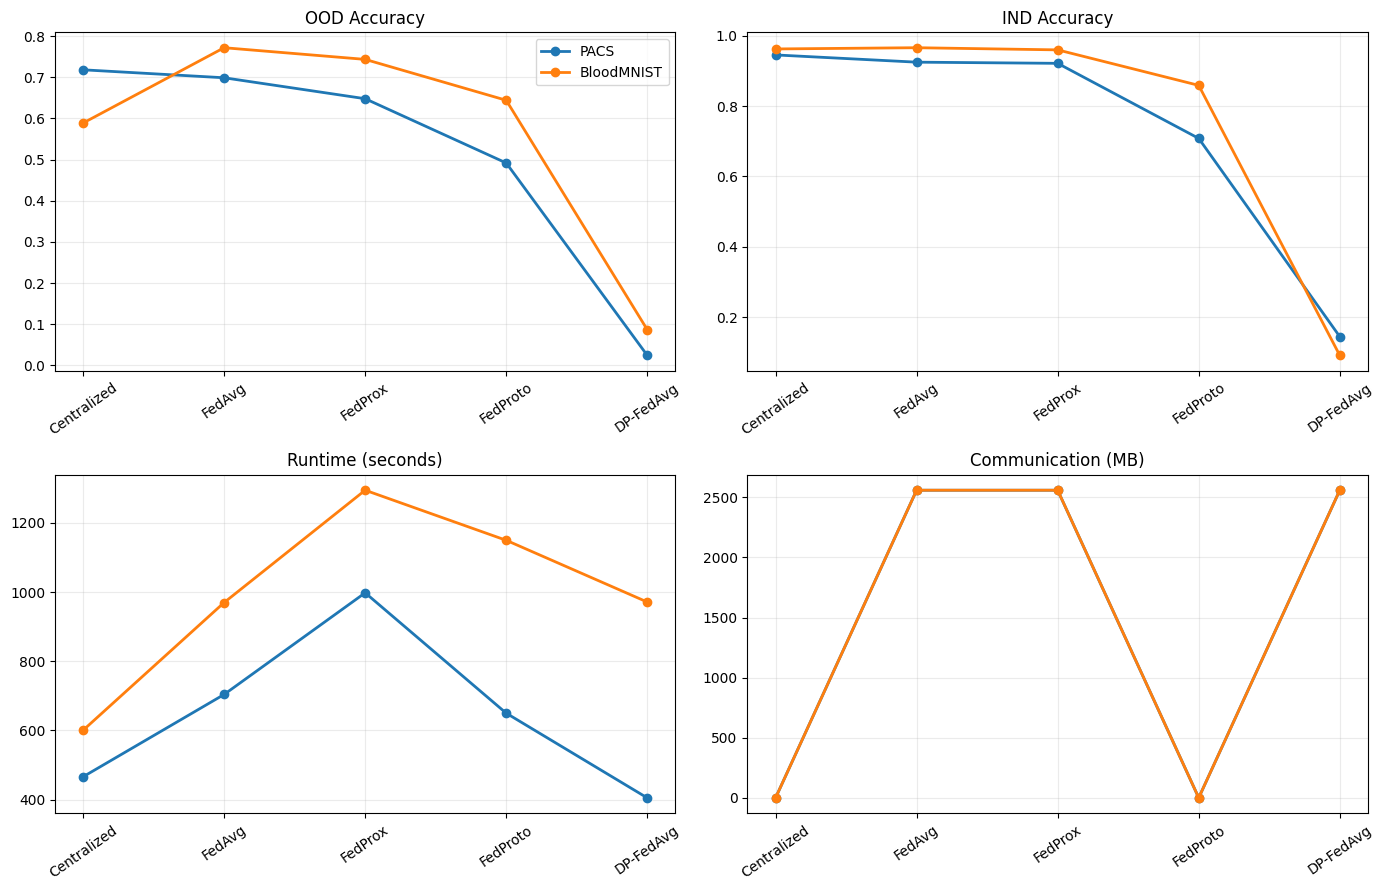

In [10]:
dataset_name_map = {PACS_DATASET: "PACS", MEDMNIST_DATASET: "BloodMNIST"}
plot_df = results_df.copy()
plot_df["dataset"] = plot_df["dataset"].map(dataset_name_map)
method_order = ["Centralized", "FedAvg", "FedProx", "FedProto", "DP-FedAvg"]
colors = {
    "Centralized": "#4E79A7",
    "FedAvg": "#59A14F",
    "FedProx": "#E15759",
    "FedProto": "#F28E2B",
    "DP-FedAvg": "#9C755F",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics = [
    ("ood_acc", "OOD Accuracy"),
    ("ind_acc", "IND Accuracy"),
    ("runtime_s", "Runtime (seconds)"),
    ("communication_mb", "Communication (MB)"),
]

for ax, (metric, title) in zip(axes.flat, metrics):
    for dataset_name in ["PACS", "BloodMNIST"]:
        sub = plot_df[plot_df["dataset"] == dataset_name].copy()
        sub["method"] = pd.Categorical(sub["method"], categories=method_order, ordered=True)
        sub = sub.sort_values("method")
        ax.plot(sub["method"].astype(str), sub[metric], marker="o", linewidth=2, label=dataset_name)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, alpha=0.25)

axes[0, 0].legend()
plt.tight_layout()
plt.show()

## Export to Excel

In [11]:
output_path = Path("core/outputs/image_only_results.xlsx")
output_path.parent.mkdir(parents=True, exist_ok=True)

runtime_comm_df = results_df[["dataset", "method", "runtime_s", "communication_mb"]].copy()
privacy_df = results_df[["dataset", "method", "leakage_proxy_acc_gap", "mia_conf_auc", "mia_loss_auc", "mia_conf_attack_acc", "mia_loss_attack_acc"]].copy()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="all_results", index=False)
    runtime_comm_df.to_excel(writer, sheet_name="runtime_comm", index=False)
    privacy_df.to_excel(writer, sheet_name="privacy", index=False)

print(f"Saved to: {output_path.resolve()}")

Saved to: /Users/shashank.ajmani/Desktop/NTU Assigments/Data Privacy/Learning/DomainFL/core/core/outputs/image_only_results.xlsx
